# Reproducibility_Astro — Analysis Notebook

Analyses results from the Reproducibility_Astro pipeline across four research questions:

1. **RQ1** — How are Jupyter notebooks *referenced* in astrophysics publications?
2. **RQ2** — How *stable* are those referenced notebooks?
3. **RQ3** — Where are notebooks *hosted/stored*?
4. **RQ4** — How do notebooks *receive citations*?

**Prerequisites:** Run `collect.sh`, then `run.sh` (batch mode) before executing this notebook.  
**DB:** `output/db/db.sqlite`

Run from the repo root:
```bash
jupyter notebook analysis/reproducibility_analysis.ipynb
```

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import os, sys
from pathlib import Path

# Resolve repo root whether launched from analysis/ or project root
cwd = Path.cwd()
repo_root = cwd.parent if cwd.name == 'analysis' else cwd
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))
print(f'Repo root: {repo_root}')

DB_PATH = repo_root / 'output' / 'db' / 'db.sqlite'
assert DB_PATH.exists(), f'DB not found at {DB_PATH} — run collect.sh and run.sh first'
print(f'DB: {DB_PATH}')

Repo root: /home/jovyan
DB: /home/jovyan/output/db/db.sqlite


In [2]:
# ── Install / import dependencies ─────────────────────────────────────────────
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'pandas>=1.5.0', 'matplotlib>=3.6.0', 'seaborn>=0.12.0'],
    stdout=subprocess.DEVNULL)

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
sns.set_theme(style='whitegrid')

FIGURES = repo_root / 'analysis' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

def load(sql, **kwargs):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(sql, conn, **kwargs)

print('Ready.')

Ready.


In [3]:
# ── Quick DB overview ─────────────────────────────────────────────────────────
with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)

print('Tables in DB:')
for t in tables['name']:
    count = load(f'SELECT COUNT(*) AS n FROM "{t}"')['n'][0]
    print(f'  {t:<35} {count:>6} rows')

Tables in DB:
  article                               1283 rows
  author                               27634 rows
  journal                                124 rows
  notebook_mentions                        0 rows
  repositories                          3624 rows
  sqlite_sequence                          4 rows


---
## RQ1 — How are notebooks referenced in publications?

Notebook category distribution:
         notebook_category  count
              jupyter_only   1155
       jupyter_with_github     61
       jupyter_with_zenodo     60
jupyter_with_github_zenodo      7


/tmp/ipykernel_196/3088797192.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_df, x='count', y='notebook_category', ax=ax, palette='Blues_d')


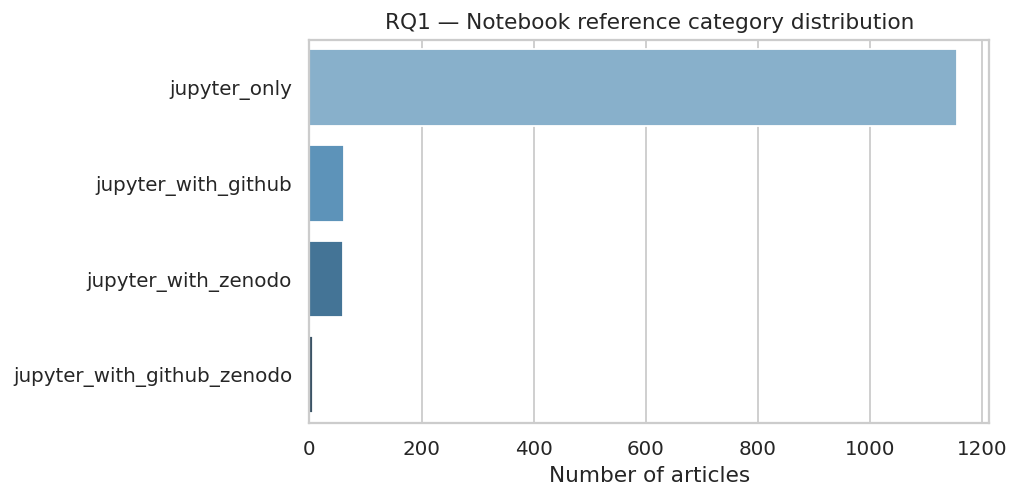

In [4]:
# Distribution of notebook_category across all articles
cat_df = load("""
    SELECT notebook_category, COUNT(*) AS count
    FROM article
    WHERE notebook_category IS NOT NULL
    GROUP BY notebook_category
    ORDER BY count DESC
""")

print('Notebook category distribution:')
print(cat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=cat_df, x='count', y='notebook_category', ax=ax, palette='Blues_d')
ax.set_xlabel('Number of articles')
ax.set_ylabel('')
ax.set_title('RQ1 — Notebook reference category distribution')
plt.tight_layout()
plt.savefig(FIGURES / 'rq1_notebook_categories.png')
plt.show()

In [5]:
# Mention context — how notebooks are described in paper text
mentions_df = load("""
    SELECT section, link_form, host, COUNT(*) AS count
    FROM notebook_mentions
    GROUP BY section, link_form, host
    ORDER BY count DESC
    LIMIT 30
""")
print('Top mention contexts (section × link_form × host):')
print(mentions_df.to_string(index=False))

Top mention contexts (section × link_form × host):
Empty DataFrame
Columns: [section, link_form, host, count]
Index: []


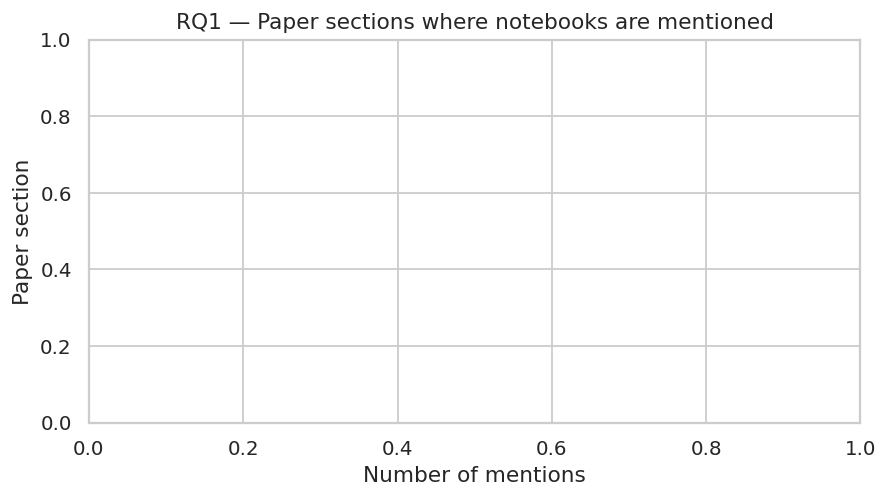

In [6]:
# Which paper sections contain notebook mentions?
section_df = load("""
    SELECT COALESCE(section, 'unknown') AS section, COUNT(*) AS count
    FROM notebook_mentions
    GROUP BY section
    ORDER BY count DESC
""")

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=section_df, x='count', y='section', ax=ax, palette='Greens_d')
ax.set_xlabel('Number of mentions')
ax.set_ylabel('Paper section')
ax.set_title('RQ1 — Paper sections where notebooks are mentioned')
plt.tight_layout()
plt.savefig(FIGURES / 'rq1_mention_sections.png')
plt.show()

In [7]:
# Link form breakdown — URL, DOI, bare name, etc.
linkform_df = load("""
    SELECT COALESCE(link_form, 'unknown') AS link_form, COUNT(*) AS count
    FROM notebook_mentions
    GROUP BY link_form
    ORDER BY count DESC
""")
print('Link forms used to reference notebooks:')
print(linkform_df.to_string(index=False))

Link forms used to reference notebooks:
Empty DataFrame
Columns: [link_form, count]
Index: []


---
## RQ2 — How stable are referenced notebooks?

In [8]:
# Check if repo_targets table exists (requires run.sh to have completed)
with sqlite3.connect(DB_PATH) as conn:
    has_targets = conn.execute(
        "SELECT COUNT(*) FROM sqlite_master WHERE type='table' AND name='repo_targets'"
    ).fetchone()[0]

if not has_targets:
    print('repo_targets table not found — run run.sh (batch mode) first, then re-run from this cell.')
else:
    rt_df = load('SELECT * FROM repo_targets')
    print(f'repo_targets rows: {len(rt_df)}')
    print(rt_df.dtypes)

repo_targets table not found — run run.sh (batch mode) first, then re-run from this cell.


In [9]:
# RRS score distribution
rrs_df = load("""
    SELECT rrs, score_E, score_A, score_D, score_C, score_S
    FROM repo_targets
    WHERE rrs IS NOT NULL
""")

print(f'Scored repos: {len(rrs_df)}')
print(rrs_df.describe().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rrs_df['rrs'].dropna(), bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('RRS score (0–100)')
ax.set_ylabel('Number of repos')
ax.set_title('RQ2 — Distribution of RRS scores')
plt.tight_layout()
plt.savefig(FIGURES / 'rq2_rrs_distribution.png')
plt.show()

DatabaseError: Execution failed on sql '
    SELECT rrs, score_E, score_A, score_D, score_C, score_S
    FROM repo_targets
    WHERE rrs IS NOT NULL
': no such table: repo_targets

In [ ]:
# Per-category score breakdown (E, A, D, C, S)
cat_scores = rrs_df[['score_E','score_A','score_D','score_C','score_S']].mean().reset_index()
cat_scores.columns = ['category', 'mean_score']
cat_scores['category'] = cat_scores['category'].str.replace('score_', '')

CAT_LABELS = {'E': 'Environment', 'A': 'Data Access', 'D': 'Documentation',
              'C': 'Code Quality', 'S': 'Reproducibility Signals'}
cat_scores['label'] = cat_scores['category'].map(CAT_LABELS)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=cat_scores, x='mean_score', y='label', ax=ax, palette='RdYlGn')
ax.set_xlabel('Mean score (0–100)')
ax.set_ylabel('')
ax.set_title('RQ2 — Mean RRS sub-scores by category')
ax.axvline(50, color='grey', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES / 'rq2_rrs_subcategories.png')
plt.show()

In [ ]:
# Top and bottom 10 repos by RRS
ranked = load("""
    SELECT repository, paper_doi, rrs, score_E, score_A, score_D, score_C, score_S
    FROM repo_targets
    WHERE rrs IS NOT NULL
    ORDER BY rrs DESC
""")

print('--- Top 10 repos by RRS ---')
print(ranked.head(10).to_string(index=False))
print()
print('--- Bottom 10 repos by RRS ---')
print(ranked.tail(10).to_string(index=False))

---
## RQ3 — Where are notebooks hosted?

In [ ]:
# Host type distribution from repositories table
host_df = load("""
    SELECT COALESCE(host_type, 'unknown') AS host_type, COUNT(*) AS count
    FROM repositories
    GROUP BY host_type
    ORDER BY count DESC
""")

print('Hosting platform distribution:')
print(host_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(host_df['count'], labels=host_df['host_type'], autopct='%1.1f%%',
       colors=sns.color_palette('pastel'))
ax.set_title('RQ3 — Notebook hosting platforms')
plt.tight_layout()
plt.savefig(FIGURES / 'rq3_hosting_platforms.png')
plt.show()

In [ ]:
# notebook_category breakdown — what fraction include GitHub, Zenodo, personal hosting
hosting_cat = load("""
    SELECT notebook_category, COUNT(*) AS count
    FROM article
    WHERE notebook_category IS NOT NULL
    GROUP BY notebook_category
    ORDER BY count DESC
""")

total = hosting_cat['count'].sum()
hosting_cat['pct'] = (hosting_cat['count'] / total * 100).round(1)
print(hosting_cat.to_string(index=False))

In [ ]:
# Hosting by arXiv category — do some subfields prefer certain platforms?
subfield_host = load("""
    SELECT
        a.subject,
        a.notebook_category,
        COUNT(*) AS count
    FROM article a
    WHERE a.subject IS NOT NULL AND a.notebook_category IS NOT NULL
    GROUP BY a.subject, a.notebook_category
    ORDER BY a.subject, count DESC
""")
print(subfield_host.head(40).to_string(index=False))

---
## RQ4 — How do notebooks receive citations?

In [ ]:
# DOI presence — do papers with notebooks have DOIs?
doi_df = load("""
    SELECT
        CASE WHEN doi IS NOT NULL AND doi != '' THEN 'Has DOI' ELSE 'No DOI' END AS doi_status,
        COUNT(*) AS count
    FROM article
    GROUP BY doi_status
""")
print('Article DOI presence:')
print(doi_df.to_string(index=False))

In [ ]:
# Zenodo presence as a proxy for citable notebook archiving
zenodo_df = load("""
    SELECT
        CASE
            WHEN notebook_category LIKE '%zenodo%' THEN 'Has Zenodo'
            ELSE 'No Zenodo'
        END AS zenodo_status,
        COUNT(*) AS count
    FROM article
    WHERE notebook_category IS NOT NULL
    GROUP BY zenodo_status
""")
print('Zenodo archiving (citable notebooks):')
print(zenodo_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].pie(doi_df['count'], labels=doi_df['doi_status'],
            autopct='%1.1f%%', colors=['#4CAF50','#F44336'])
axes[0].set_title('Article DOI presence')

axes[1].pie(zenodo_df['count'], labels=zenodo_df['zenodo_status'],
            autopct='%1.1f%%', colors=['#2196F3','#9E9E9E'])
axes[1].set_title('Zenodo archiving (citable notebooks)')

plt.suptitle('RQ4 — Citation infrastructure for notebooks', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'rq4_citation_infrastructure.png')
plt.show()

In [ ]:
# Repos with paper_doi in repo_targets — cross-reference execution results with papers
if has_targets:
    doi_exec = load("""
        SELECT
            CASE WHEN paper_doi IS NOT NULL AND paper_doi != '' THEN 'Has DOI' ELSE 'No DOI' END AS doi_status,
            COUNT(*) AS count,
            ROUND(AVG(rrs), 1) AS avg_rrs
        FROM repo_targets
        GROUP BY doi_status
    """)
    print('Executed repos — DOI presence vs avg RRS:')
    print(doi_exec.to_string(index=False))

---
## Summary

In [ ]:
# ── Pipeline summary statistics ────────────────────────────────────────────────
n_articles  = load('SELECT COUNT(*) AS n FROM article')['n'][0]
n_repos     = load('SELECT COUNT(*) AS n FROM repositories')['n'][0]
n_mentions  = load('SELECT COUNT(*) AS n FROM notebook_mentions')['n'][0]
n_scored    = load('SELECT COUNT(*) AS n FROM repo_targets WHERE rrs IS NOT NULL')['n'][0] if has_targets else 0

print('=' * 50)
print('PIPELINE SUMMARY')
print('=' * 50)
print(f'Articles collected     : {n_articles}')
print(f'Repositories found     : {n_repos}')
print(f'Notebook mentions      : {n_mentions}')
print(f'Repos scored (RRS)     : {n_scored}')
if has_targets and n_scored > 0:
    avg_rrs = load('SELECT ROUND(AVG(rrs),1) AS avg FROM repo_targets WHERE rrs IS NOT NULL')['avg'][0]
    print(f'Mean RRS score         : {avg_rrs}')
print('=' * 50)
print(f'Figures saved to: {FIGURES}')